In [7]:
library(SCEVAN)
library(dplyr)
library(Seurat)
library(future)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
primary <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/seurat-mnn_integration_sct-norm_primary-tumor_alternative.rds')
primary

An object of class Seurat 
48434 features across 5422 samples within 2 assays 
Active assay: SCT (24217 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

In [3]:
primary <- UpdateSeuratObject(primary)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘mnn’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in SCT

Updating slots in SCT_nn

Setting default assay of SCT_nn to SCT

Updating slots in SCT_snn

Setting default assay of SCT_snn to SCT

Updating slots in mnn

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for RunFastMNN.SCT to SCT

Setting assay used for SCTransform.RNA to RNA

Setting assay used for RunUMAP.SCT.mnn to SCT

Setting assay used for FindNeighbors.SCT.mnn to SCT

No assay information could be found for FindClusters

Warning message:
“Adding a command log without an assay associated with it”
Validating object structure for Assay ‘RNA’

Validating object structure for SCTAssay ‘SCT’

Validating object structure for Graph ‘SCT_nn’


In [5]:
primary@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.7,seurat_clusters
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>
core_AAACCCACAGGTGGAT-1,core,5115,2476,0.03910068,5121,2476,7,7
core_AAACCCACATGCACTA-1,core,7311,2856,0.12310217,6012,2856,4,4
core_AAACCCATCCTCCACA-1,core,6460,2981,0.12383901,5873,2981,0,0
core_AAACGAAAGGGCGAAG-1,core,9227,4170,0.06502655,6498,4113,1,1
core_AAACGAACAGGAGGTT-1,core,4235,2389,0.75560803,4570,2389,0,0
core_AAACGAATCGTCGATA-1,core,1268,701,3.54889590,3721,905,8,8
core_AAACGCTCAGCTGCCA-1,core,6448,2646,0.03101737,5813,2646,4,4
core_AAACGCTGTTAAAGTG-1,core,4475,2324,1.85474860,4708,2324,10,10
core_AAAGAACAGATTTGCC-1,core,13791,4969,0.41331303,4971,2377,1,1


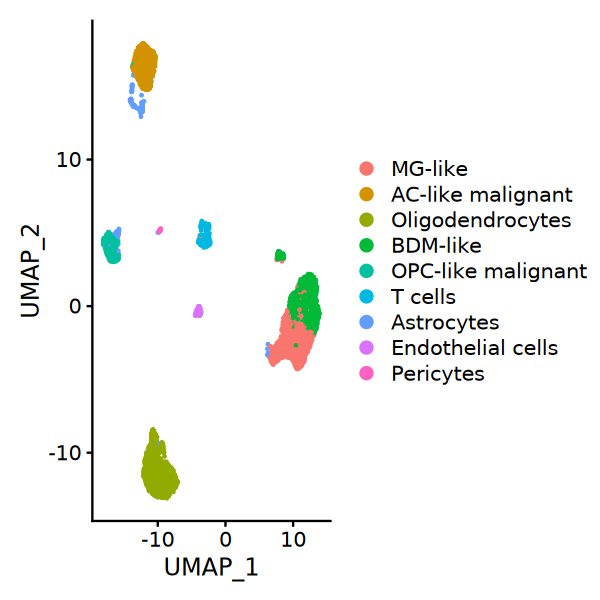

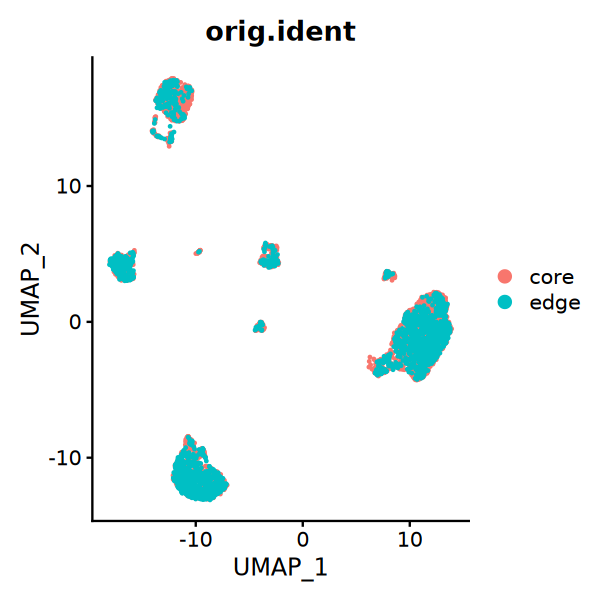

In [6]:
options(repr.plot.height = 5, repr.plot.width = 5)
DimPlot(primary)
DimPlot(primary, group.by = 'orig.ident')

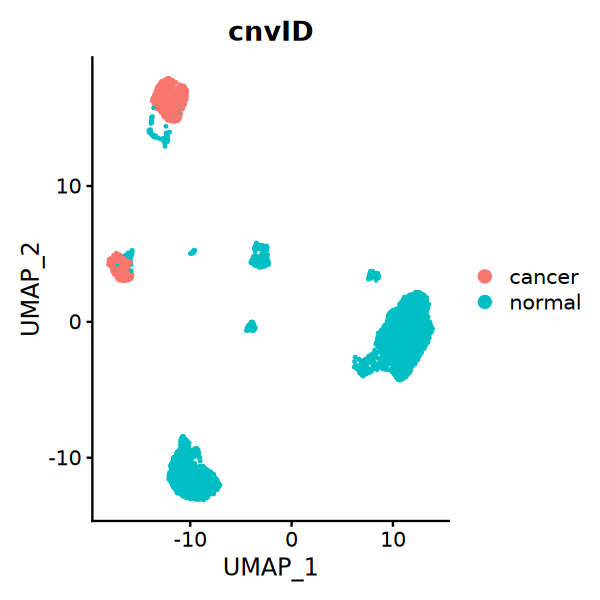

In [8]:
primary$cnvID <- ifelse(
  primary@active.ident %in% c("AC-like malignant", "OPC-like malignant"),
  "cancer",
  "normal"
)
DimPlot(primary, group.by = 'cnvID')

In [14]:
ascites <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/seurat-mnn_integration_sct-norm_all-prettx_no-low-complex-cells.rds')
ascites

An object of class Seurat 
44017 features across 21704 samples within 2 assays 
Active assay: SCT (21525 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

In [15]:
ascites <- UpdateSeuratObject(ascites)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘mnn’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in SCT

Updating slots in SCT_nn

Setting default assay of SCT_nn to SCT

Updating slots in SCT_snn

Setting default assay of SCT_snn to SCT

Updating slots in mnn

Updating slots in umap

Setting umap DimReduc to global

Setting assay used for RunFastMNN.SCT to SCT

Setting assay used for SCTransform.RNA to RNA

Setting assay used for RunUMAP.SCT.mnn to SCT

Setting assay used for FindNeighbors.SCT.mnn to SCT

No assay information could be found for FindClusters

Warning message:
“Adding a command log without an assay associated with it”
Validating object structure for Assay ‘RNA’

Validating object structure for SCTAssay ‘SCT’

Validating object structure for Graph ‘SCT_nn’


In [16]:
ascites@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.5,seurat_clusters
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>
first-prettx_AAACCCAAGCAACTTC-1,first,4759,1592,3.046859,5012,1592,0,0
first-prettx_AAACCCACAAGCGAAC-1,first,3324,1272,2.286402,4688,1279,3,3
first-prettx_AAACCCACATCGATCA-1,first,5223,1831,2.106069,5223,1831,3,3
first-prettx_AAACCCACATGCTGCG-1,first,3237,1297,2.873031,4690,1313,0,0
first-prettx_AAACCCAGTACCGGCT-1,first,1522,753,2.431012,4373,1020,14,14
first-prettx_AAACCCAGTAGAGATT-1,first,1675,880,2.089552,4428,1074,1,1
first-prettx_AAACCCAGTATCGATC-1,first,4230,1626,2.695035,4829,1626,0,0
first-prettx_AAACCCATCAATGCAC-1,first,3683,1208,2.280749,4790,1212,11,11
first-prettx_AAACCCATCCGGTAGC-1,first,3387,1278,2.332448,4722,1282,3,3


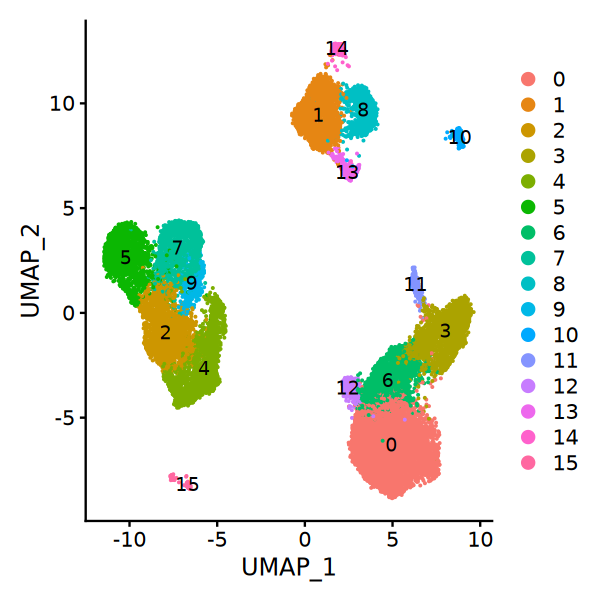

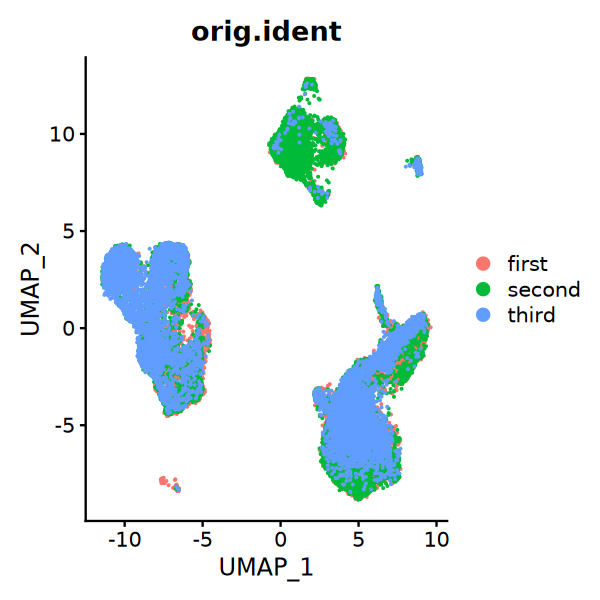

In [17]:
options(repr.plot.height = 5, repr.plot.width = 5)
DimPlot(ascites, label=TRUE)
DimPlot(ascites, group.by = 'orig.ident')

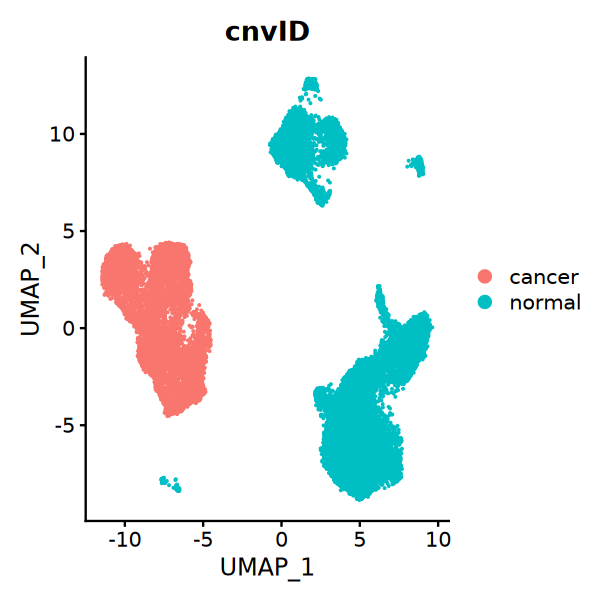

In [18]:
ascites$cnvID <- ifelse(
  ascites@active.ident %in% c("2", "4", "5", "7", "9"),
  "cancer",
  "normal"
)
DimPlot(ascites, group.by = 'cnvID')

In [19]:
listCountMtx <- list(core = GetAssayData(subset(primary, 
                                                orig.ident == 'core'),
                                         slot = 'counts'), 
                     edge =  GetAssayData(subset(primary, 
                                                orig.ident == 'edge'),
                                         slot = 'counts'), 
                     first =  GetAssayData(subset(ascites, 
                                                orig.ident == 'first'),
                                         slot = 'counts'), 
                     second =  GetAssayData(subset(ascites, 
                                                orig.ident == 'second'),
                                         slot = 'counts'), 
                     third =  GetAssayData(subset(ascites, 
                                                orig.ident == 'third'),
                                         slot = 'counts')
                    )

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


In [21]:
listNormCells <- list(core = colnames(subset(primary, cnvID=='normal' & orig.ident=='core')), 
                     edge =  colnames(subset(primary, cnvID=='normal'& orig.ident=='edge')), 
                     first =  colnames(subset(ascites, cnvID=='normal'& orig.ident=='first')), 
                     second =  colnames(subset(ascites, cnvID=='normal'& orig.ident=='second')), 
                     third =  colnames(subset(ascites, cnvID=='normal'& orig.ident=='third'))
                    )

In [23]:
results <- SCEVAN::multiSampleComparisonClonalCN(listCountMtx, listNormCells, analysisName = "case_report", organism = "human" , par_cores = 64)

[1] " raw data - genes: 24217 cells: 3058"
[1] "1) Filter: cells > 200 genes"
[1] "2) Filter: genes > 10% of cells"
[1] "7228 genes past filtering"
[1] "3) Annotations gene coordinates"
[1] "6519 genes annotated"
[1] "4) Filter: genes involved in the cell cycle"
[1] "6226 genes past filtering "
[1] "5)  Filter: cells > 5genes per chromosome "
[1] "6) Log Freeman Turkey transformation"
[1] "A total of 3042 cells, 6226 genes after preprocessing"
[1] "7) Measuring baselines (confident normal cells)"
[1] "8) Smoothing data"
[1] "9) Segmentation (VegaMC)"
[1] "10) Adjust baseline"
[1] "11) plot heatmap"
[1] "found 1594 tumor cells"
[1] "time classify tumor cells:  52.6693005561829"
[1] " raw data - genes: 24217 cells: 2364"
[1] "1) Filter: cells > 200 genes"
[1] "2) Filter: genes > 10% of cells"
[1] "7563 genes past filtering"
[1] "3) Annotations gene coordinates"
[1] "6720 genes annotated"
[1] "4) Filter: genes involved in the cell cycle"
[1] "6417 genes past filtering "
[1] "5)  Filter: c

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”


[1] "low data quality"
[1] "2) Filter: genes > 5% of cells"
[1] "8074 genes past filtering"
[1] "3) Annotations gene coordinates"
[1] "7622 genes annotated"
[1] "4) Filter: genes involved in the cell cycle"
[1] "7154 genes past filtering "
[1] "5)  Filter: cells > 5genes per chromosome "
[1] "6) Log Freeman Turkey transformation"
[1] "A total of 8692 cells, 7154 genes after preprocessing"
[1] "7) Measuring baselines (confident normal cells)"
[1] "8) Smoothing data"
[1] "9) Segmentation (VegaMC)"
[1] "10) Adjust baseline"
[1] "11) plot heatmap"
[1] "found 2220 tumor cells"
[1] "time classify tumor cells:  4.36219805876414"
[1] " raw data - genes: 21525 cells: 7570"
[1] "1) Filter: cells > 200 genes"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”


[1] "low data quality"
[1] "2) Filter: genes > 5% of cells"
[1] "8554 genes past filtering"
[1] "3) Annotations gene coordinates"
[1] "8079 genes annotated"
[1] "4) Filter: genes involved in the cell cycle"
[1] "7582 genes past filtering "
[1] "5)  Filter: cells > 5genes per chromosome "
[1] "6) Log Freeman Turkey transformation"
[1] "A total of 7546 cells, 7582 genes after preprocessing"
[1] "7) Measuring baselines (confident normal cells)"
[1] "8) Smoothing data"
[1] "9) Segmentation (VegaMC)"
[1] "10) Adjust baseline"
[1] "11) plot heatmap"
[1] "found 3773 tumor cells"
[1] "time classify tumor cells:  3.8780375957489"


Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been dis

In [24]:
results

,class,confidentNormal
,<chr>,<chr>
core_AAACCCACAGGTGGAT-1,normal,yes
core_AAACCCACATGCACTA-1,normal,yes
core_AAACCCATCCTCCACA-1,normal,yes
core_AAACGAAAGGGCGAAG-1,tumor,NA
core_AAACGAACAGGAGGTT-1,normal,yes
core_AAACGAATCGTCGATA-1,normal,yes
core_AAACGCTCAGCTGCCA-1,normal,yes
core_AAACGCTGTTAAAGTG-1,normal,yes
core_AAAGAACAGATTTGCC-1,tumor,NA
